In [1]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

In [2]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df = pd.read_csv(path_data/"data.csv")
df = df.drop(columns=['Unnamed: 0']).query('2021<year | year<=2020').copy()
df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NAC'], errors='coerce')

In [101]:
df_nac_nov2023 = df[(df['FECHA_NAC'].dt.year == 2023) & (df['FECHA_NAC'].dt.month == 11)]
df_nac_nov2019 = df[(df['FECHA_NAC'].dt.year == 2019) & (df['FECHA_NAC'].dt.month == 11)]
df_nac_nov2022 = df[(df['FECHA_NAC'].dt.year == 2022) & (df['FECHA_NAC'].dt.month == 11)]

In [12]:
hospitalizations_by_week = df.groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_elegibles = df.query('elegibilidad==year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')
hospitalizations_by_week_non_elegibles = df.query('elegibilidad!=year').groupby(['year', 'epiweek']).size().reset_index(name='hospitalizations')


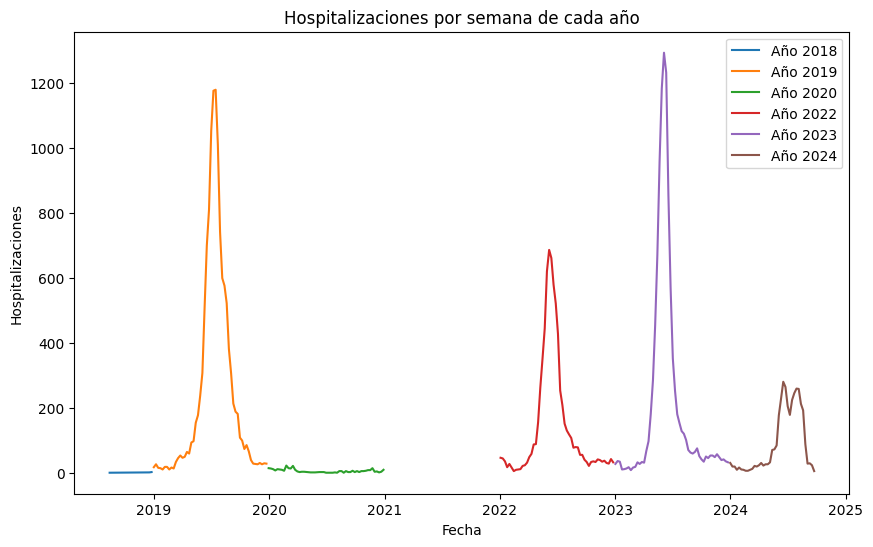

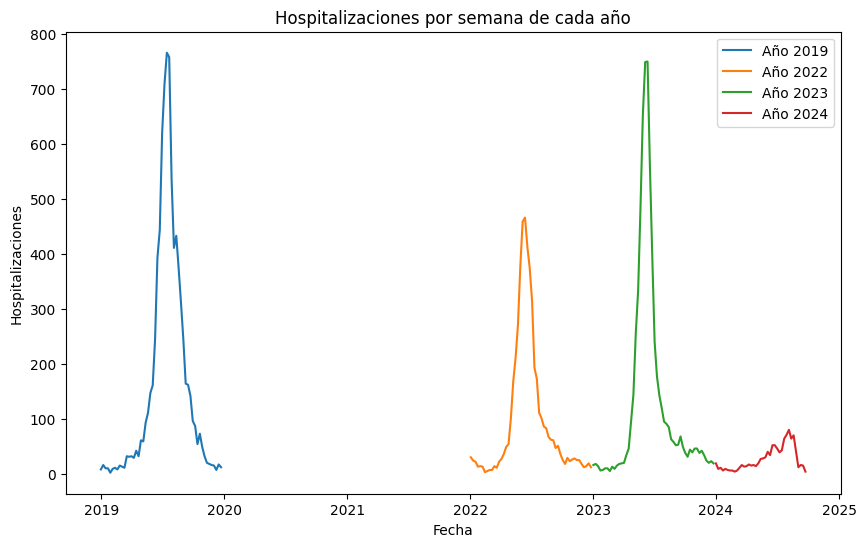

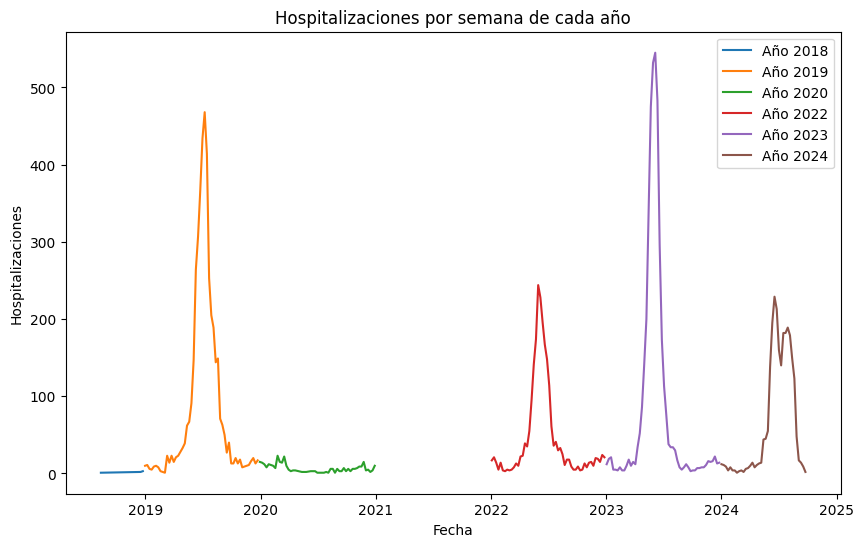

In [19]:
for i in [hospitalizations_by_week, hospitalizations_by_week_elegibles, hospitalizations_by_week_non_elegibles]:
    data = i.copy()
    data['date'] = pd.to_datetime(data[['year', 'epiweek']].assign(day=1).apply(lambda x: pd.Timestamp.fromisocalendar(x['year'], x['epiweek'], x['day']), axis=1))

    # Graficar los datos de hospitalizaciones por año
    plt.figure(figsize=(10,6))

    # Filtrar por cada año y graficar las hospitalizaciones correspondientes
    for year in data['year'].unique():
        yearly_data = data[data['year'] == year]
        plt.plot(yearly_data['date'], yearly_data['hospitalizations'], label=f'Año {year}')

    # Añadir etiquetas y título
    plt.xlabel('Fecha')
    plt.ylabel('Hospitalizaciones')
    plt.title('Hospitalizaciones por semana de cada año')
    plt.legend()

    # Mostrar gráfico
    plt.show()




In [20]:
data = hospitalizations_by_week_non_elegibles.copy()

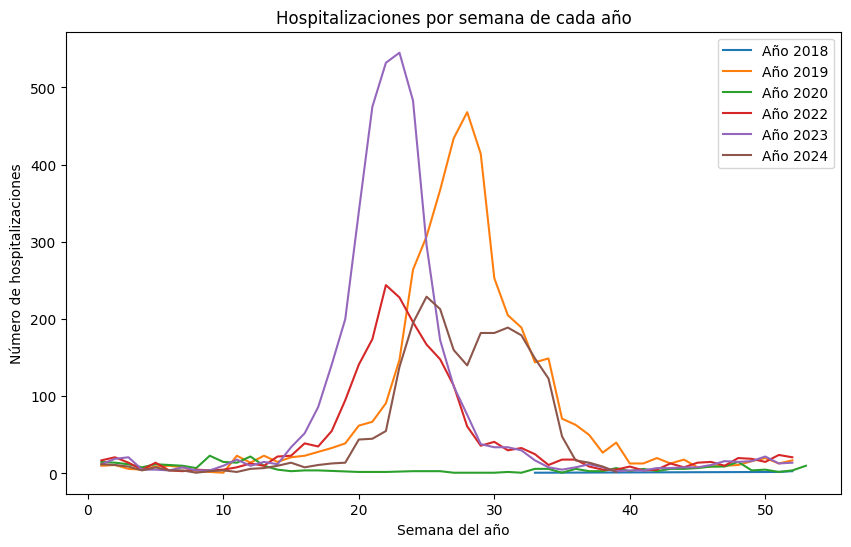

In [24]:
# Crear el gráfico
plt.figure(figsize=(10,6))

# Graficar hospitalizaciones por cada año con elegibilidad correspondiente
for year in data['year'].unique():
    yearly_data = data[data['year'] == year]
    plt.plot(yearly_data['epiweek'], yearly_data['hospitalizations'], label=f'Año {year}')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Hospitalizaciones por semana de cada año')
plt.legend()

# Mostrar el gráfico
plt.show()


Tamaño de X_train: 34
Tamaño de y_train: 34
Coeficiente (pendiente): [0.94755811]
Intercepto: 14.118643745747882


C:\Users\ntrig\AppData\Local\Temp\ipykernel_11968\3145990082.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 5


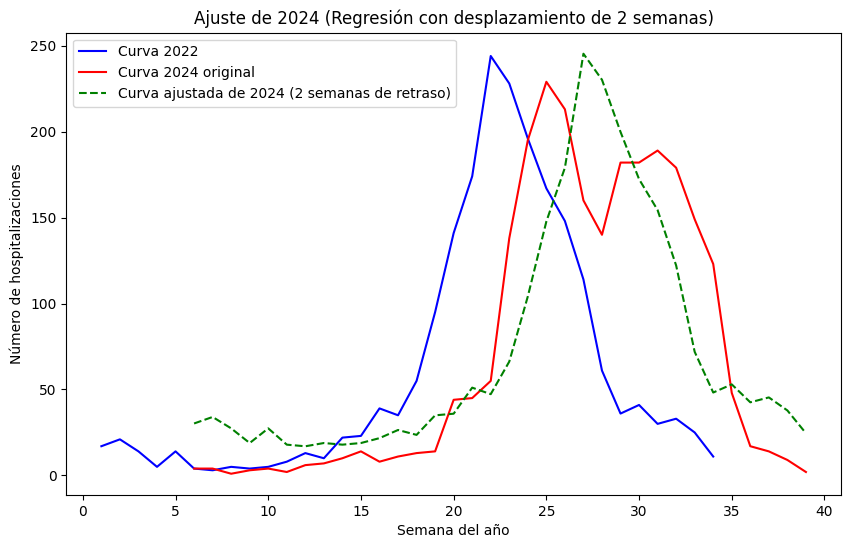

In [30]:
hospitalizations_2022 = data[data['year'] == 2022]

hospitalizations_2024 = data[data['year'] == 2024]

hospitalizations_2022['epiweek_shifted'] = hospitalizations_2022['epiweek'] + 5

epiweeks_2024 = hospitalizations_2024['epiweek'].unique()  
hospitalizations_2022_train = hospitalizations_2022[hospitalizations_2022['epiweek_shifted'].isin(epiweeks_2024)]  

hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2022_train['epiweek_shifted'])]

X_train = hospitalizations_2022_train['hospitalizations'].values.reshape(-1, 1)
y_train = hospitalizations_2024_train['hospitalizations'].values

print(f"Tamaño de X_train: {len(X_train)}")
print(f"Tamaño de y_train: {len(y_train)}")

model = LinearRegression()
model.fit(X_train, y_train)

coeficiente = model.coef_  
intercepto = model.intercept_  

print(f"Coeficiente (pendiente): {coeficiente}")
print(f"Intercepto: {intercepto}")

predicted_2024 = model.predict(X_train)

plt.figure(figsize=(10,6))

plt.plot(hospitalizations_2022_train['epiweek'], hospitalizations_2022_train['hospitalizations'], label='Curva 2022', color='blue')

plt.plot(hospitalizations_2024_train['epiweek'], hospitalizations_2024_train['hospitalizations'], label='Curva 2024 original', color='red')

plt.plot(hospitalizations_2022_train['epiweek_shifted'], predicted_2024, label='Curva ajustada de 2024 (2 semanas de retraso)', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Ajuste de 2024 (Regresión con desplazamiento de 2 semanas)')
plt.legend()
plt.show()




In [68]:
hospitalizations_2022_full = data.assign(
    year_ext = lambda x: np.where((x.year == 2023) & (x.epiweek <= 13), 2022, x.year),
    epiweek_ext = lambda x: np.where((x.year == 2023) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    ).query('year_ext==2022').copy()

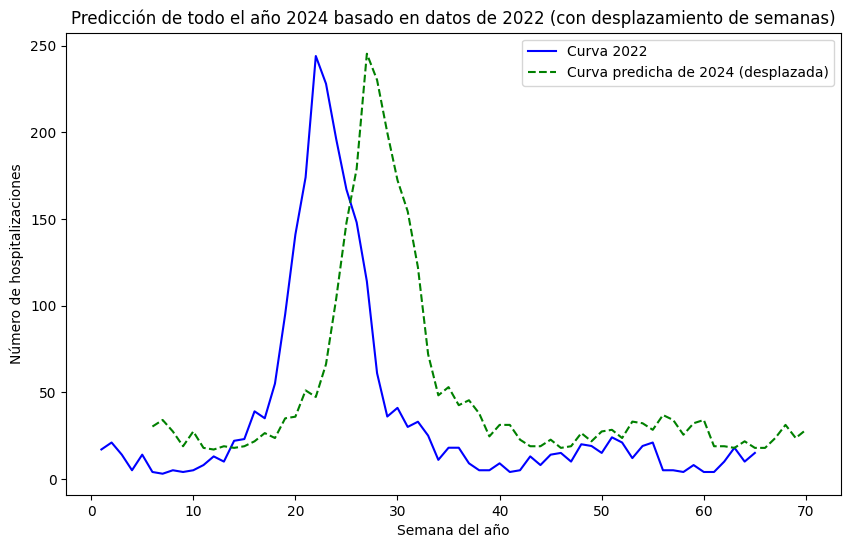

In [75]:
# Usar los datos completos de 2022 para predecir todo 2024
#hospitalizations_2022_full = data[(data['year'] == 2022) | ((data['year'] == 2023) & (data['epiweek'] <= 13))]

hospitalizations_2022_full['epiweek_shifted'] = hospitalizations_2022_full['epiweek_ext'] + 5

# Usar las hospitalizaciones de 2022 desplazadas como entrada para predecir todo 2024
X_full = hospitalizations_2022_full['hospitalizations'].values.reshape(-1, 1)

# Predecir usando el modelo ya entrenado
predicted_2024_full = model.predict(X_full)

# Graficar las hospitalizaciones originales de 2022 y las predicciones para 2024
plt.figure(figsize=(10,6))

# Graficar las hospitalizaciones originales de 2022
plt.plot(hospitalizations_2022_full['epiweek_ext'], hospitalizations_2022_full['hospitalizations'], label='Curva 2022', color='blue')

# Graficar las predicciones de 2024
plt.plot(hospitalizations_2022_full['epiweek_shifted'], predicted_2024_full, label='Curva predicha de 2024 (desplazada)', linestyle='--', color='green')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('Predicción de todo el año 2024 basado en datos de 2022 (con desplazamiento de semanas)')
plt.legend()

# Mostrar el gráfico
plt.show()


In [ ]:
# Paso 1: Crear una columna que identifique a los nacidos en noviembre de 2022
df = df.assign(nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2022) & (x.FECHA_NAC.dt.month == 11), 1, 0))

# Paso 2: Calcular el número total de hospitalizaciones por semana y año
hospitalizations_total = df.groupby(['year', 'epiweek']).size().reset_index(name='total_hospitalizations')

# Paso 3: Calcular el número de hospitalizaciones solo para los nacidos en noviembre de 2022
hospitalizations_nov = df[df['nac_nov'] == 1].groupby(['year', 'epiweek']).size().reset_index(name='nov_hospitalizations')

# Paso 4: Unir ambos DataFrames (total de hospitalizaciones y hospitalizaciones de nacidos en noviembre)
hospitalizations = pd.merge(hospitalizations_total, hospitalizations_nov, on=['year', 'epiweek'], how='left')

# Rellenar valores NaN en 'nov_hospitalizations' con 0, ya que puede que algunas semanas no haya hospitalizaciones de nacidos en noviembre
hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

hospitalizations['epiweek_shifted'] = hospitalizations['epiweek'] + 5

# Paso 5: Calcular el porcentaje de hospitalizaciones que son de nacidos en noviembre
hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['total_hospitalizations']) * 100

hospitalizations = hospitalizations.assign(
    year_ext = lambda x: np.where((x.year == 2023) & (x.epiweek <= 13), 2022, x.year),
    epiweek_ext = lambda x: np.where((x.year == 2023) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    ).copy()


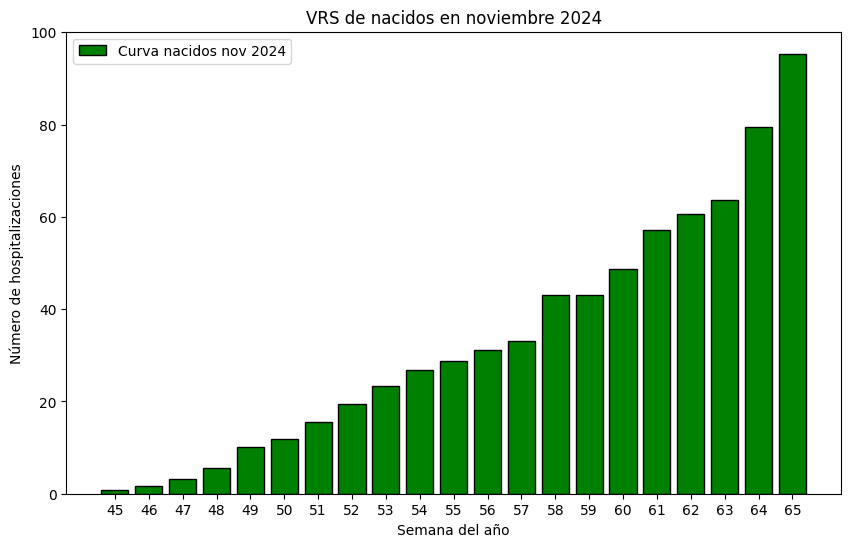

In [89]:
weeks_2024 = hospitalizations.query('((year_ext == 2023) & (epiweek_ext <= 13)) | ((year_ext==2022 & epiweek_ext>=45))')['epiweek_ext'].unique() 

predictions_df = pd.DataFrame({
    'epiweek_ext': weeks_2024,
    'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
})

hospitalizations_merged = hospitalizations.query('((year_ext == 2023) & (epiweek_ext <= 13)) | ((year_ext==2022 & epiweek_ext>=45))').merge(predictions_df, on='epiweek_ext', how='left')


hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']

hospitalizations_merged = hospitalizations_merged[['year_ext', 'epiweek_ext', 'total_hospitalizations', 'predicted_2024', 'percentage_nov', 'predicted_nov_2024']]

plt.figure(figsize=(10,6))

# Graficar el histograma de nacidos en noviembre 2024 usando barras
plt.bar(hospitalizations_merged['epiweek_ext'], hospitalizations_merged['predicted_nov_2024'].cumsum(), color='green', edgecolor='black', label='Curva nacidos nov 2024')

# Añadir etiquetas y título
plt.xlabel('Semana del año')
plt.ylabel('Número de hospitalizaciones')
plt.title('VRS de nacidos en noviembre 2024')

# Mostrar todos los valores enteros en el eje X
plt.xticks(np.arange(hospitalizations_merged['epiweek_ext'].min(), hospitalizations_merged['epiweek_ext'].max()+1, 1))

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()